# Libaries and functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.special import jv
import sys
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc
sys.path.insert(0, '/home/jbreda/PROseq/scripts/FourierTransform')
from fourier_transform import fourier_transform
from scipy.stats import vonmises



# remove version number from gene/transcript id
def remove_version_number(x):
    return x.split('.')[0]

def linear_regression(x,y):
    n = x.shape[0]
    X = np.ones((n,2))
    X[:,1] = x
    Σ = np.linalg.inv(X.T @ X)
    β = Σ @ X.T @ y
    σ2 = np.sum((y - X @ β)**2)/(n-2)
    σ2_β = σ2 * Σ

    RSS = np.sum((y - X @ β)**2)
    TSS = np.sum((y - np.mean(y))**2)
    R2 = 1 - RSS / TSS
    
    return β, σ2_β, R2

def FourierTransform(x,T,ω):
    # x: data matrix (genes x time points)

    N = T.shape[0]
    f_n = np.sum(x*np.exp(-1j*ω*T),1)
    a_n = 4/N * np.abs(f_n)
    φ_n = -np.arctan2(np.imag(f_n),np.real(f_n))
    μ = 1/N * np.sum(x,1)

    x_hat = μ[:,None] + 0.5 * a_n[:,None] * np.cos(ω * T[None,:] - φ_n[:,None])
    sig2_res = np.var(x - x_hat,1)
    sig2_tot = np.var(x,1)
    R2 = np.zeros(sig2_res.shape)
    R2[sig2_tot==0] = 0
    R2[sig2_tot!=0] = 1 - sig2_res[sig2_tot!=0] / sig2_tot[sig2_tot!=0]
    p = 3
    pval = 1 - beta.cdf(R2, (p - 1) / 2, (N - p) / 2)
    φ_n[φ_n<0] += np.pi * 2

    return φ_n, a_n, R2, pval, μ

def FourierTransform_GLS(Y,T,ω,Λ):
    # Y: data matrix (bin x time points)
    
    n_bin, n = Y.shape

    p = 3
    X = np.zeros((n, p))
    X[:,0] = np.ones(n)
    X[:,1] = np.cos(ω*T)
    X[:,2] = np.sin(ω*T)

    μ = np.zeros(n_bin)
    A = np.zeros(n_bin)
    φ = np.zeros(n_bin)
    σ2_μ = np.zeros(n_bin)
    σ2_A = np.zeros(n_bin)
    σ2_φ = np.zeros(n_bin)
    for i in range(n_bin):
        
        Σ = np.linalg.inv(X.T @ Λ[i] @ X)
        β = Σ @ X.T @ Λ[i] @ Y[i]

        μ[i], a, b = β
        σ2_μ[i], σ2_a, σ2_b = np.diag(Σ)

        A[i] = np.sqrt(a**2 + b**2)
        φ[i] = np.arctan2(b, a)
        σ2_A[i] = (np.abs(a)*σ2_a + np.abs(b)*σ2_b)/A[i]
        σ2_φ[i] = (np.abs(b)*σ2_a + np.abs(a)*σ2_b)/A[i]**2

    return μ, A, φ, σ2_μ, σ2_A, σ2_φ

def noise_model(df, pseudo_count=8, n_bin=50, do_fig=False, fig_name=None):

    idx_x = [f'CT{t:02d}{s}' for t in range(0,24,4) for s in ['+','-']]
    idx_y = [f'CT{t:02d}{s}' for t in range(24,48,4) for s in ['+','-']]
    x = np.log2(df.loc[:,idx_x].fillna(0).values.flatten()+pseudo_count)
    y = np.log2(df.loc[:,idx_y].fillna(0).values.flatten()+pseudo_count)
    ρ =  np.corrcoef(x,y)[0,1]

    # estimate error as the difference between the two measurements
    df_err = pd.DataFrame({'x':x,'y':y})
    df_err['err'] = (df_err.x - df_err.y)**2
    df_err['m'] = (df_err.x + df_err.y)/2
    df_err['m_bin'] = pd.cut(df_err.m,n_bin)
    df_err['n'] = 1
    df_err = df_err.groupby(['m_bin']).agg({'x':'mean','y':'mean','m':'mean','err':'mean','n':'sum'}).reset_index()
    # remove nan rows
    df_err = df_err.loc[~df_err.isna().any(axis=1),:]
    # remove bins with less than 10 measurements
    df_err = df_err.loc[df_err.n > 10,:]
    df_err.reset_index(drop=True, inplace=True)
    idx_err_max = np.argmax(df_err['err'].values)

    # exponential fit
    def func(x, a, lam, c):
        return a * np.exp(-lam * x) + c

    popt, pcov = curve_fit(func, df_err.loc[idx_err_max:,'m'].values, df_err.loc[idx_err_max:,'err'].values, p0=[100, 1, 0.1],bounds=([0,0,0],[np.inf,np.inf,np.inf]), maxfev=10000)
    err_max = func(df_err.at[idx_err_max,'m'], *popt)

    if do_fig:
        fig, axes = plt.subplots(1,3,figsize=(18,5))
        # 2d hgistogram of x and y
        hist, xedges, yedges = np.histogram2d(x, y, bins=100)

        ax = axes[0]
        h = ax.imshow(np.log10(hist.T), origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal', cmap='Greys')
        plt.colorbar(h)
        ax.set_title(fr'$\rho={ρ:.2f}$')

        ax = axes[1]
        #ax.scatter(x,y,s=1,c='k',alpha=.2,rasterized=True)
        ax.plot(df_err.m,df_err.m,'r.',lw=2)
        ax.plot(df_err.m - 2*np.sqrt(df_err['err']),df_err.m + 2*np.sqrt(df_err['err']),'r:',lw=1)
        ax.plot(df_err.m + 2*np.sqrt(df_err['err']),df_err.m - 2*np.sqrt(df_err['err']),'r:',lw=1)
        ax.axis('equal')
        ax.set_xlabel('measurments [0-24)')
        ax.set_ylabel('measurments [24-48)')
        ax.legend(['data','$mean(x_t,x_{t+24})$)',r'$\pm$ 2*std dev'])

        ax = axes[2]
        ax.plot(df_err['m'],df_err['err'],'k.',lw=1)
        _x = np.linspace(df_err.at[idx_err_max,'m'],df_err.loc[:,'m'].values[-1],100)
        ax.plot(_x, func(_x, *popt), 'r-',lw=1)
        ax.plot(df_err.loc[[0,idx_err_max],'m'].values,[err_max,err_max],'r-',lw=1)

        ax.title.set_text(f"y = {popt[0]:.3f} * exp(-{popt[1]:.2f} * x) + {popt[2]:.2f}")
        ax.set_xlabel('mean')
        ax.set_ylabel('var (mean squared error)')

        fig.tight_layout()
        if fig_name is not None:
            fig.savefig(fig_name)

    return popt[0], popt[1], popt[2], err_max, df_err.at[idx_err_max,'m']

def periodic_gaussians_unif(t,ρ,μ,σ2,τ=24):
        
    # Precompute all t_peaks (Gaussian centers) within mesure time ± 5σ
    t_min = t[0] - 5*np.sqrt(σ2)
    n_min = int(np.floor((t_min - μ) / τ))
    t_max = t[-1] + 5*np.sqrt(σ2)
    n_max = int(np.ceil((t_max - μ) / τ))
    t_peaks = μ + np.arange(n_min, n_max + 1) * τ  # All Gaussian centers

    # Vectorized cyclic Gaussian source term
    gaussians = 1/np.sqrt(2*np.pi*σ2) * np.exp(-(t[:, np.newaxis] - t_peaks[np.newaxis, :])**2 / (2*σ2))  # Gaussian contributions from all peaks
    dt = t[1]-t[0]
    norm = (t[-1]-t[0]+dt)/τ # Normalization factor
    return (ρ + (1-ρ)*gaussians.sum(axis=1))/norm  # Sum contributions from all peaks

def periodic_gaussians(t,μ,σ2,τ=24):
        
    # Precompute all t_peaks (Gaussian centers) within mesure time ± 5σ
    t_min = t[0] - 5*np.sqrt(σ2)
    n_min = int(np.floor((t_min - μ) / τ))
    t_max = t[-1] + 5*np.sqrt(σ2)
    n_max = int(np.ceil((t_max - μ) / τ))
    t_peaks = μ + np.arange(n_min, n_max + 1) * τ  # All Gaussian centers

    # Vectorized cyclic Gaussian source term
    gaussians = 1/np.sqrt(2*np.pi*σ2) * np.exp(-(t[:, np.newaxis] - t_peaks[np.newaxis, :])**2 / (2*σ2))  # Gaussian contributions from all peaks
    dt = t[1]-t[0]
    norm = (t[-1]-t[0]+dt)/τ # Normalization factor
    return gaussians.sum(axis=1)/norm  # Sum contributions from all peaks



# Fig 1. Data examples (Validation of the experiment and intro to the problem)
A. Short gene. Dbp or Nr1d1. Left: Pro-seq. Right: RNA-seq (Koike). Indicate phases

B. Long gene. Bmal1 or Npas2

C. Best example. ‘Essra’?

D. Eventually the phase relationship of Pro-seq compared to RNA-seq over all genes.

E. Simple transport model. Observation that phase is not constant along the transcript. Motivate the KF.


In [2]:
infile_gtf = f'../resources/genome/GRCm38/gene_annotation.gtf'
infile_core_circadian_genes = '../resources/core_circadian_clock_genes.txt'

# get genes
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)

# parse gtf and extract atributes
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name','level','tag']
# parse the gtf's 9 th column (attributes sep by ;)
for att in attributes:
    if att=='level':
        gene_gtf[att] = gene_gtf['attributes'].str.extract(att + ' (.*?);')
        continue
    else:
        gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')
# drop attribute column and set gene_id as index
gene_gtf.drop('attributes', axis=1, inplace=True)
#gene_gtf.set_index('gene_id', inplace=True)


# get circadian genes
core_circadian_genes = pd.read_csv(infile_core_circadian_genes, sep='\t').loc[:,'mm10'].values


# Load PROseq and RNAseq data 

/tmp/ipykernel_743814/2541315838.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_err = df_err.groupby(['m_bin']).agg({'x':'mean','y':'mean','m':'mean','err':'mean','n':'sum'}).reset_index()
/tmp/ipykernel_743814/2541315838.py:124: RuntimeWarning: divide by zero encountered in log10
  h = ax.imshow(np.log10(hist.T), origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='equal', cmap='Greys')
/tmp/ipykernel_743814/2541315838.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_err = df_err.groupby(['m_bin']).agg({'x':'mean','y':'mean','m':'mean','err':'mean','n':'sum'}).rese

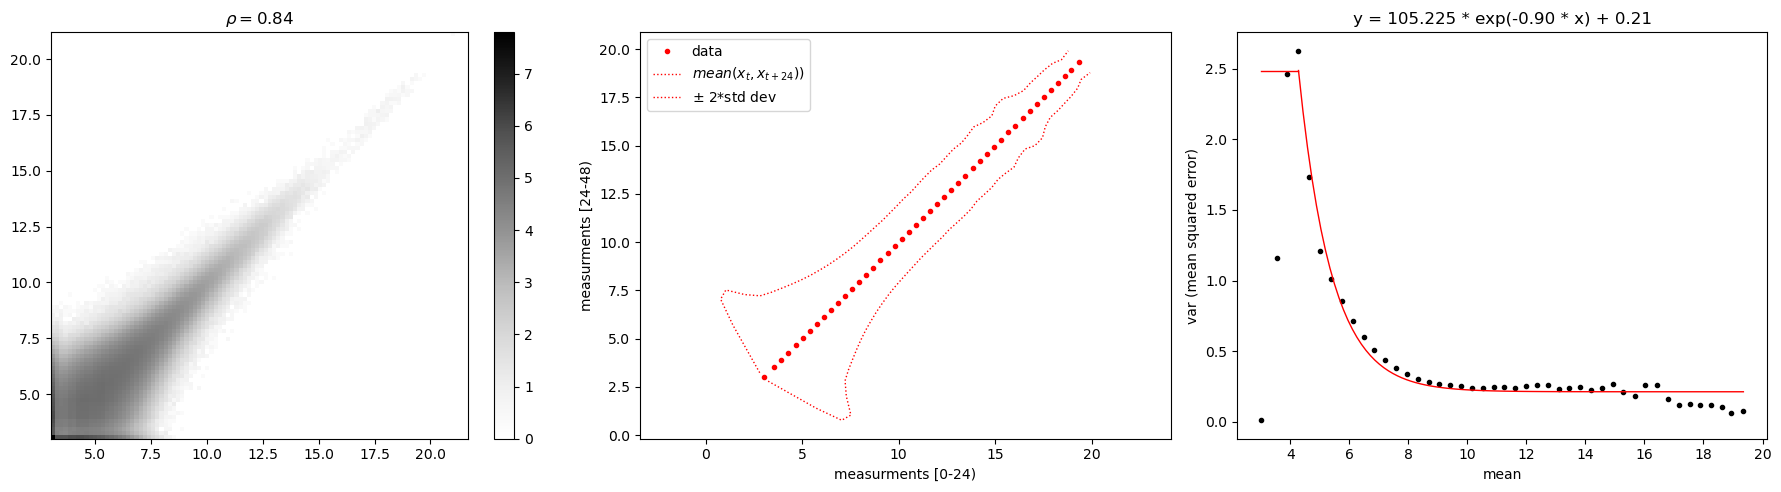

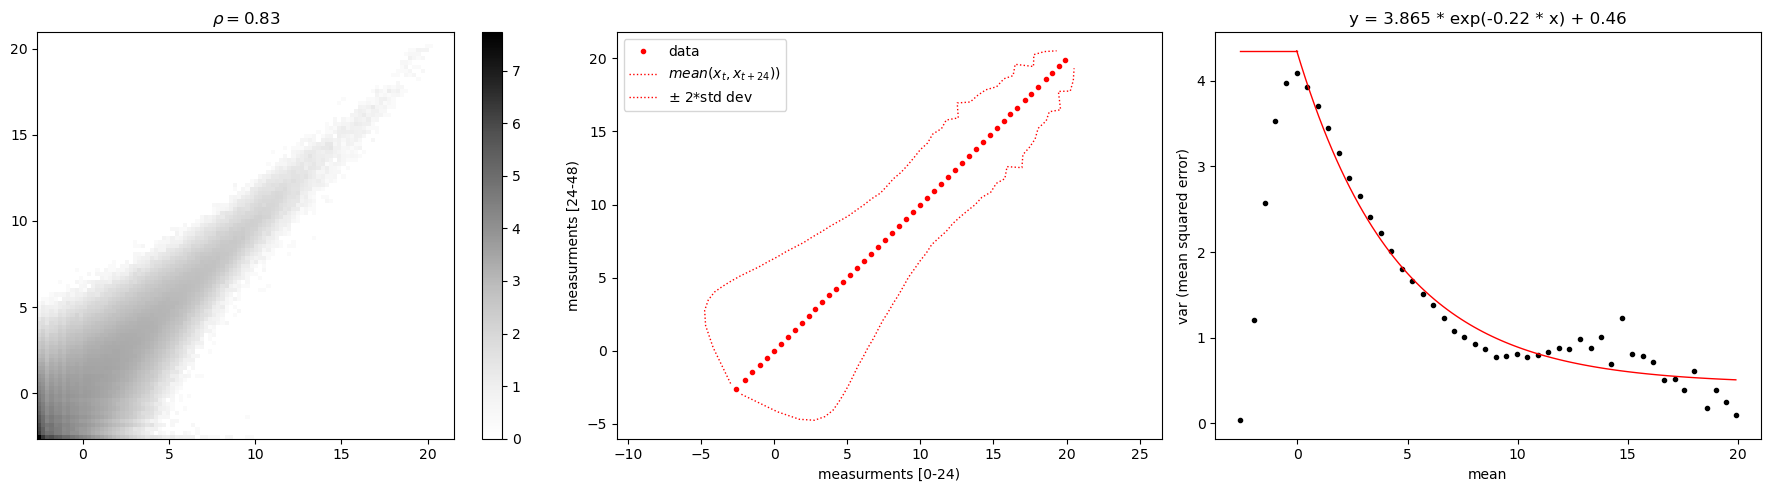

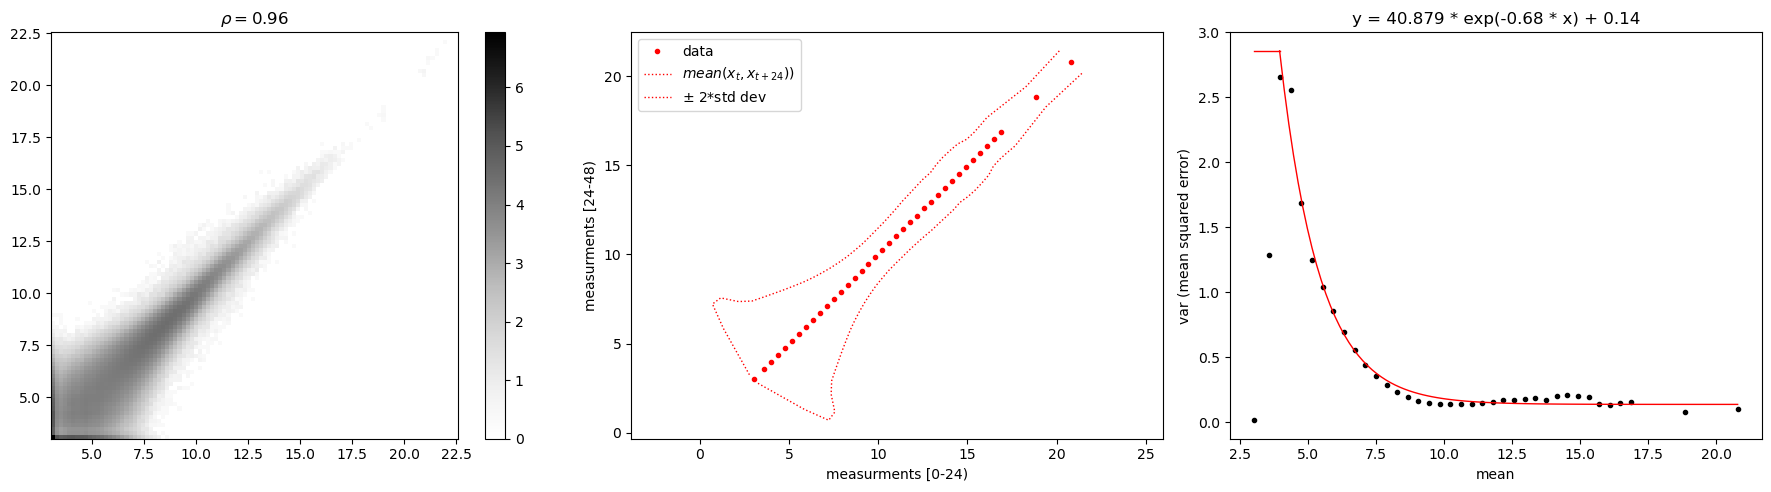

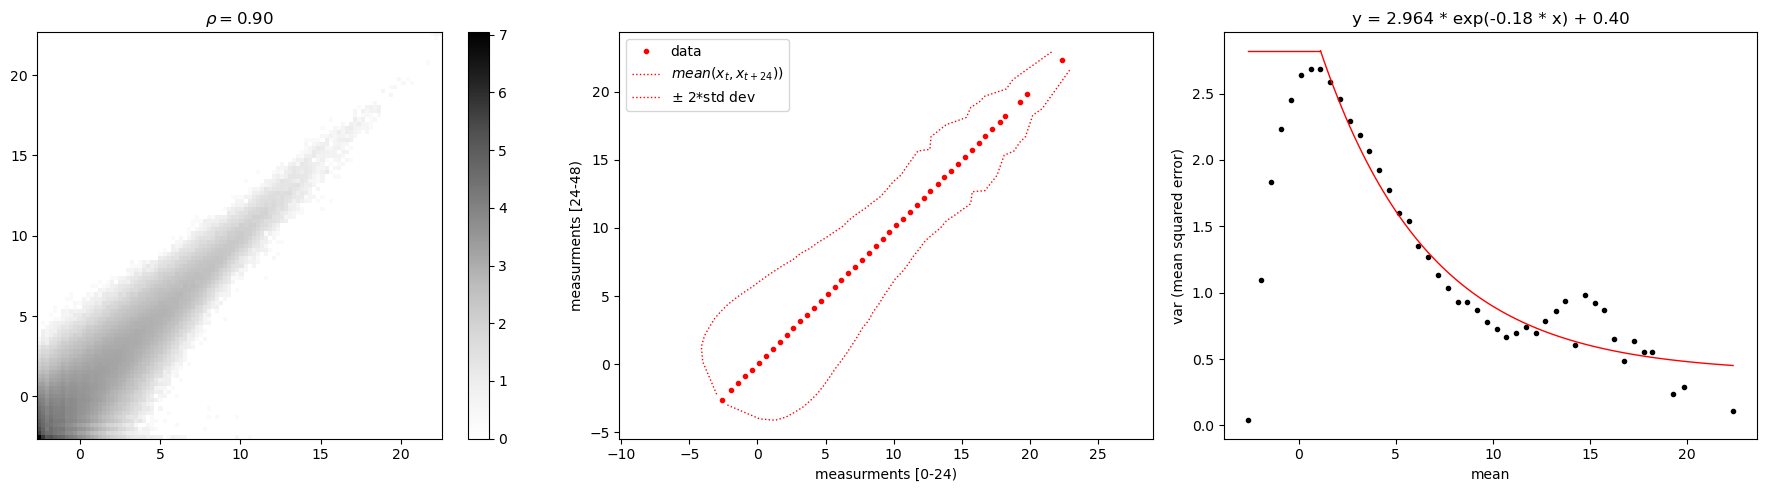

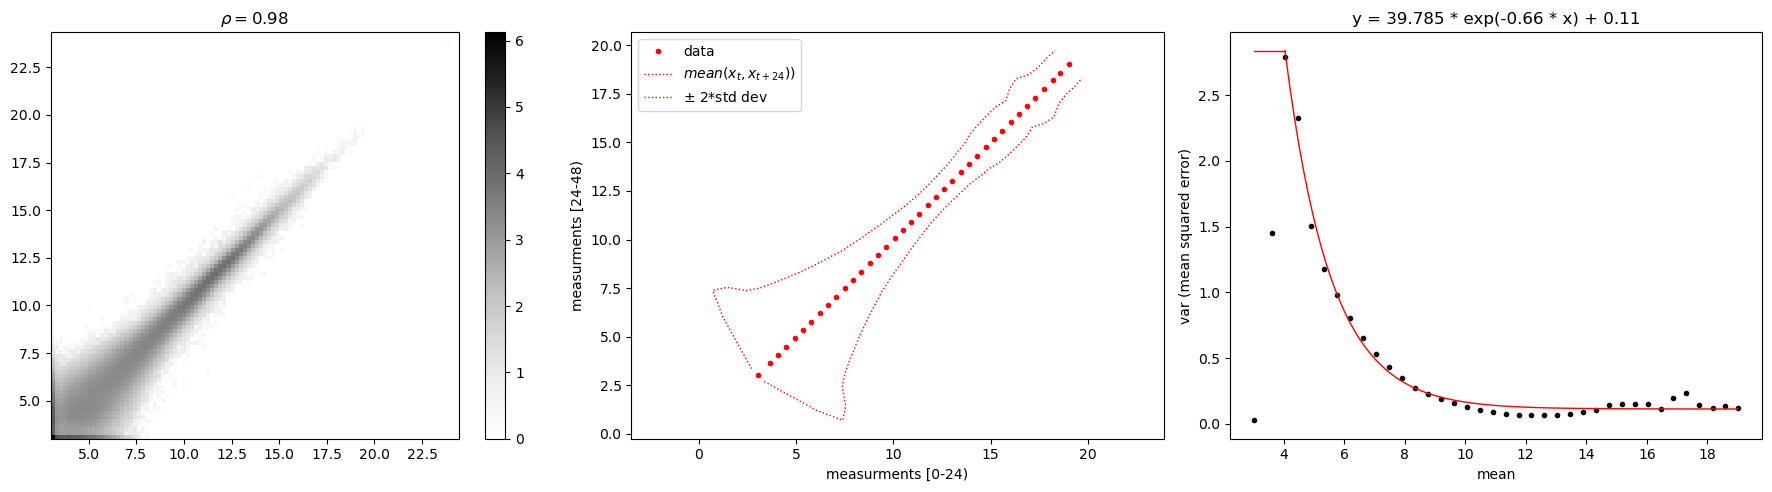

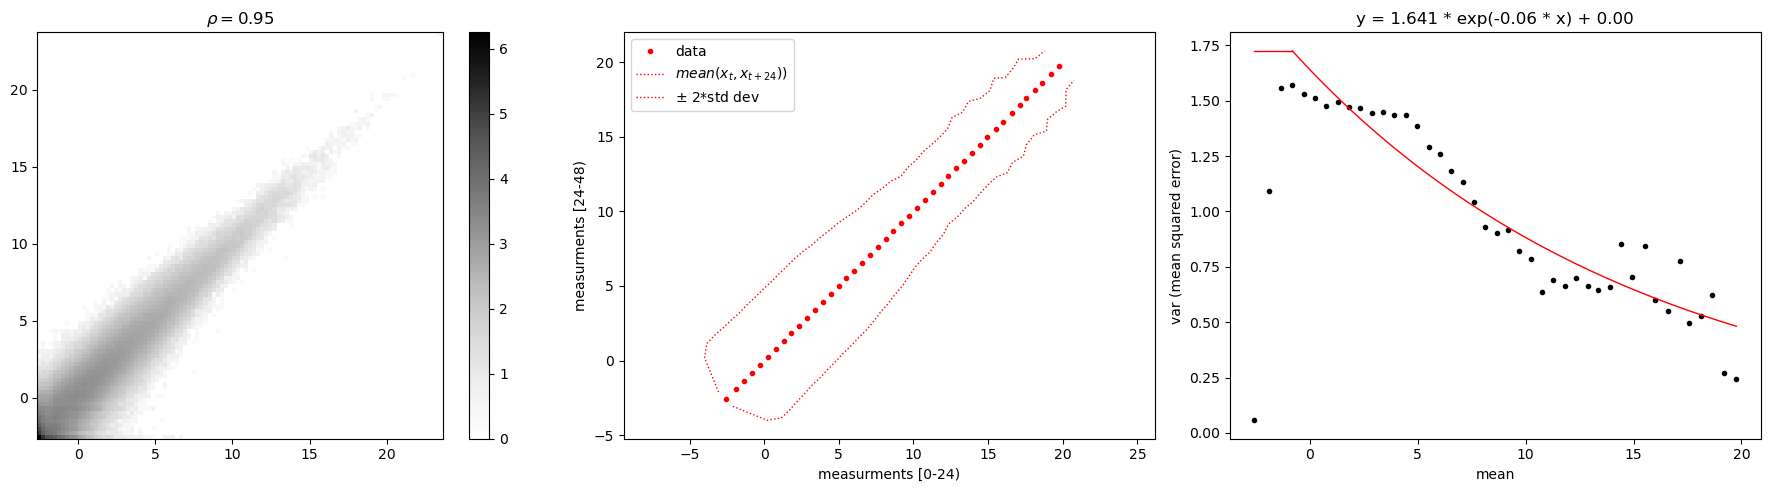

In [3]:
rnaseq_read_len = 50
PROSEQ = {}
RNASEQ = {}
noise_params = {}
noise_params['proseq'] = {}
noise_params['rnaseq'] = {}
for bin_size in [100, 1000, 10000]:
    print(f'Processing bin size: {bin_size} bp')
    # infiles
    infile_proseq = f'../results/GRCm38/binned_norm_coverage/expression_tables/bin_expression_table_bin{bin_size}bp.csv'
    infile_rnaseq = f'~/RNAseq/results/Koike_Science_2012/star/binned_norm_coverage/UniqueMultiple_rpm/expression_tables/bin_expression_table_bin{bin_size}bp.csv'
    # read data
    PROSEQ[bin_size] = pd.read_csv(infile_proseq, sep='\t')
    samples = PROSEQ[bin_size].columns.tolist()[3:]
    PROSEQ[bin_size].fillna(0,inplace=True)
    #proseq.loc[:,samples] /= bin_size
    RNASEQ[bin_size] = pd.read_csv(infile_rnaseq, sep='\t')
    RNASEQ[bin_size].fillna(0,inplace=True)
    #rnaseq.loc[:,samples] /= bin_size

    a, b, c, e_max, m_e_max = noise_model(PROSEQ[bin_size],do_fig=True,pseudo_count=8)
    noise_params['proseq'][bin_size] = {'a':a,'b':b,'c':c,'e_max':e_max,'m_e_max':m_e_max}
    a, b, c, e_max, m_e_max = noise_model(RNASEQ[bin_size],do_fig=True,pseudo_count=8/rnaseq_read_len)
    noise_params['rnaseq'][bin_size] = {'a':a,'b':b,'c':c,'e_max':e_max,'m_e_max':m_e_max}
    


In [116]:
my_gene = 'Arntl'    

my_gtf = gene_gtf.loc[(gene_gtf.gene_name == my_gene),:]
coords = my_gtf.loc[(my_gtf.feature == 'gene'),['chrom','start','end','strand']].values
print(my_gene,coords.shape[0])

n_transcripts = my_gtf.loc[(my_gtf.feature == 'transcript'),:].transcript_id.nunique()

for coord in coords:
    chr = coord[0]
    start = coord[1]
    end = coord[2]
    strand = coord[3]
    len = end - start

Arntl 1


Dbp
Nr1d1
Arntl
Npas2
Per2
Erbb4
Wwox


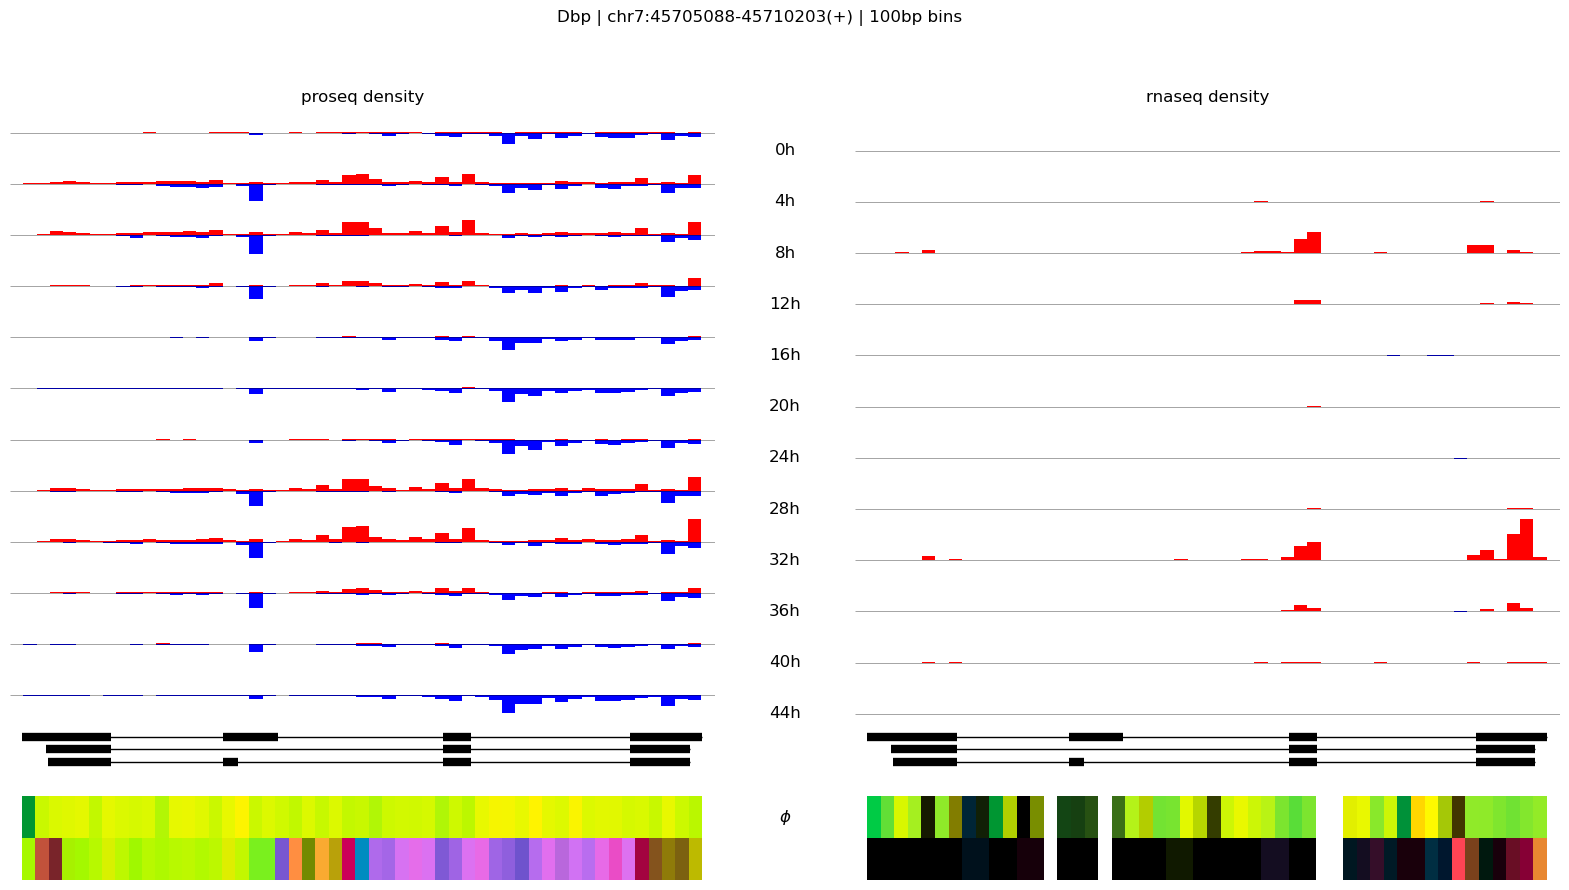

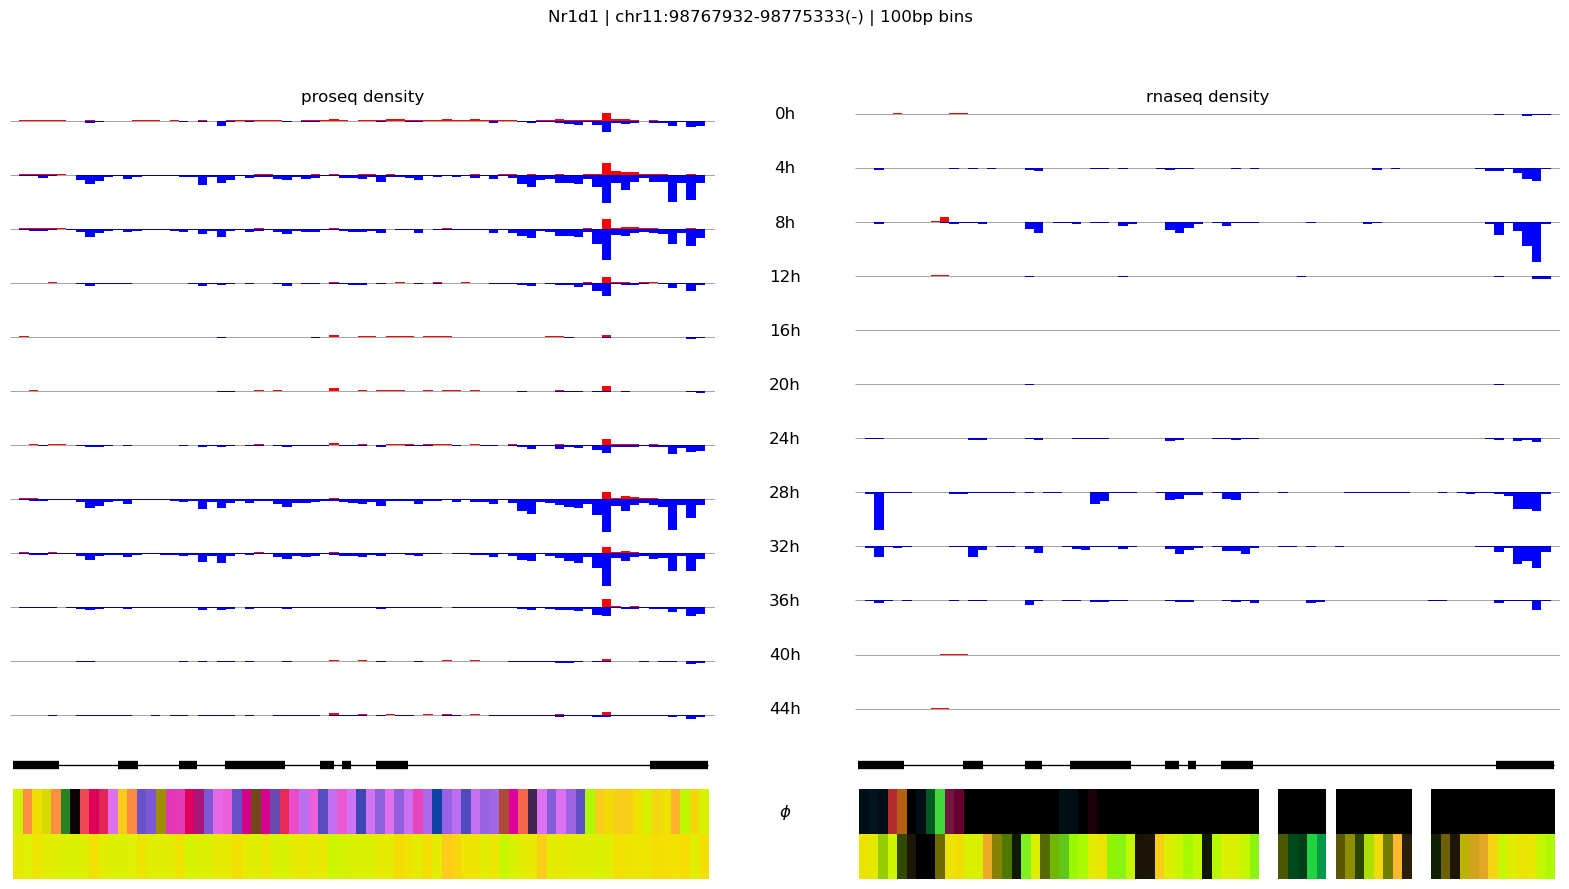

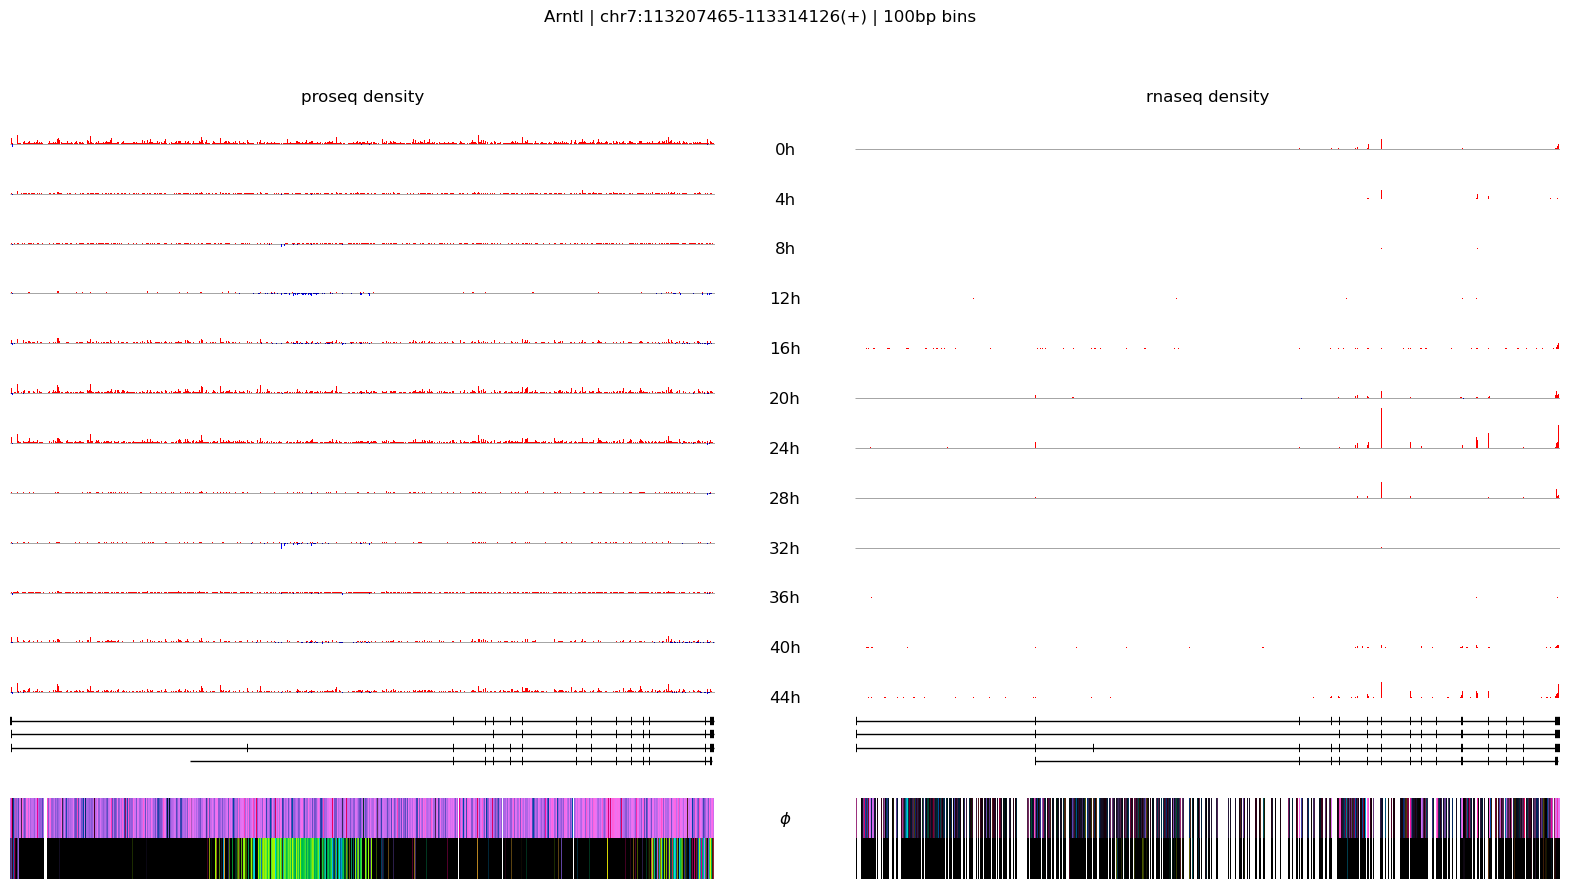

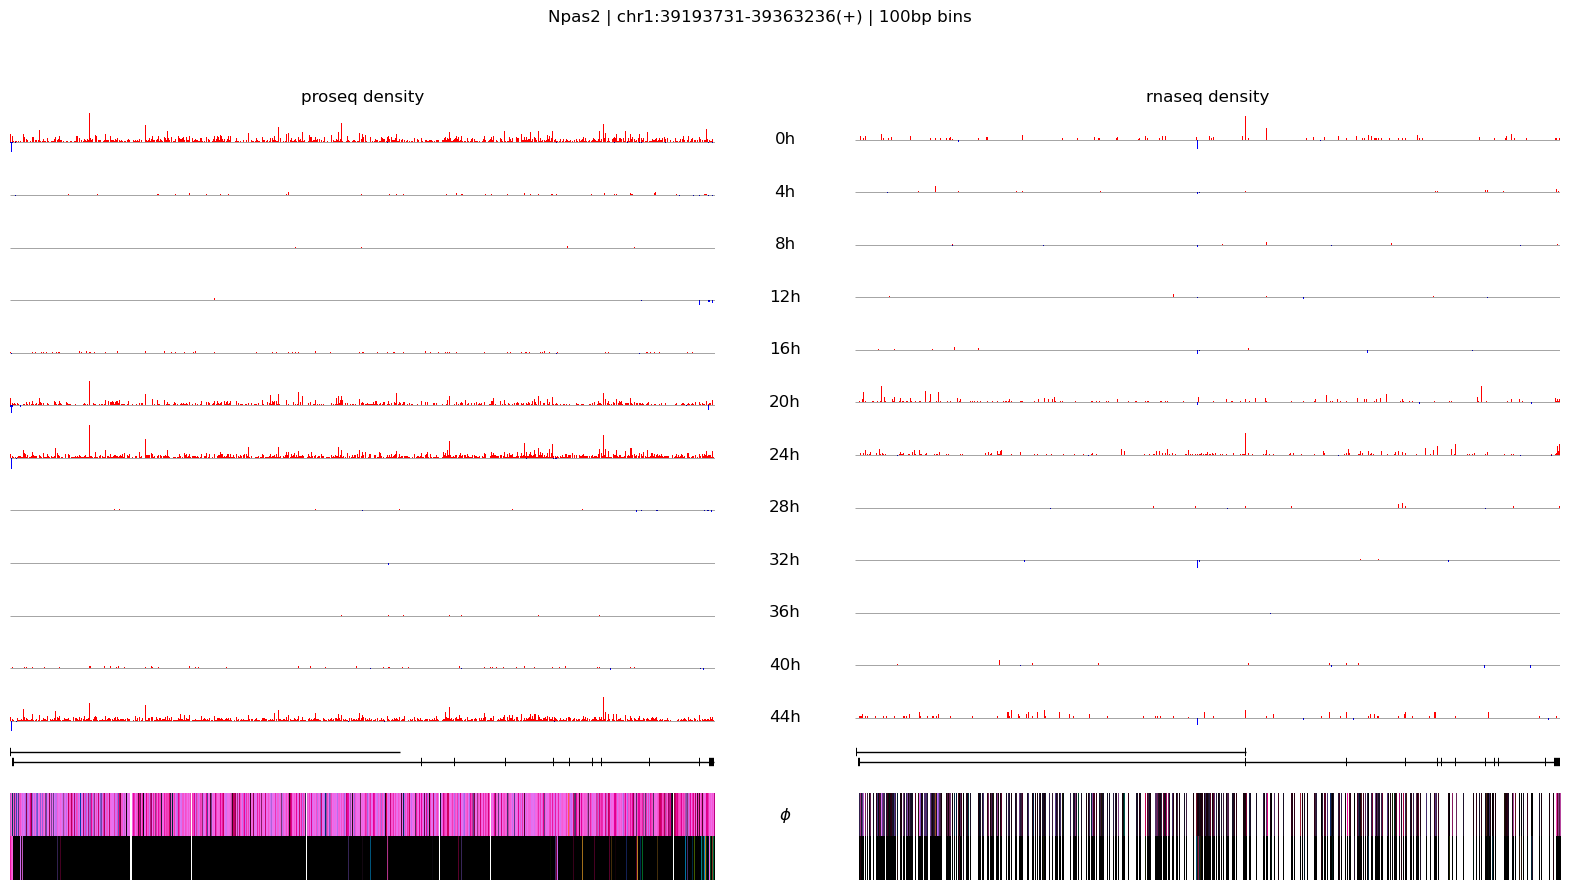

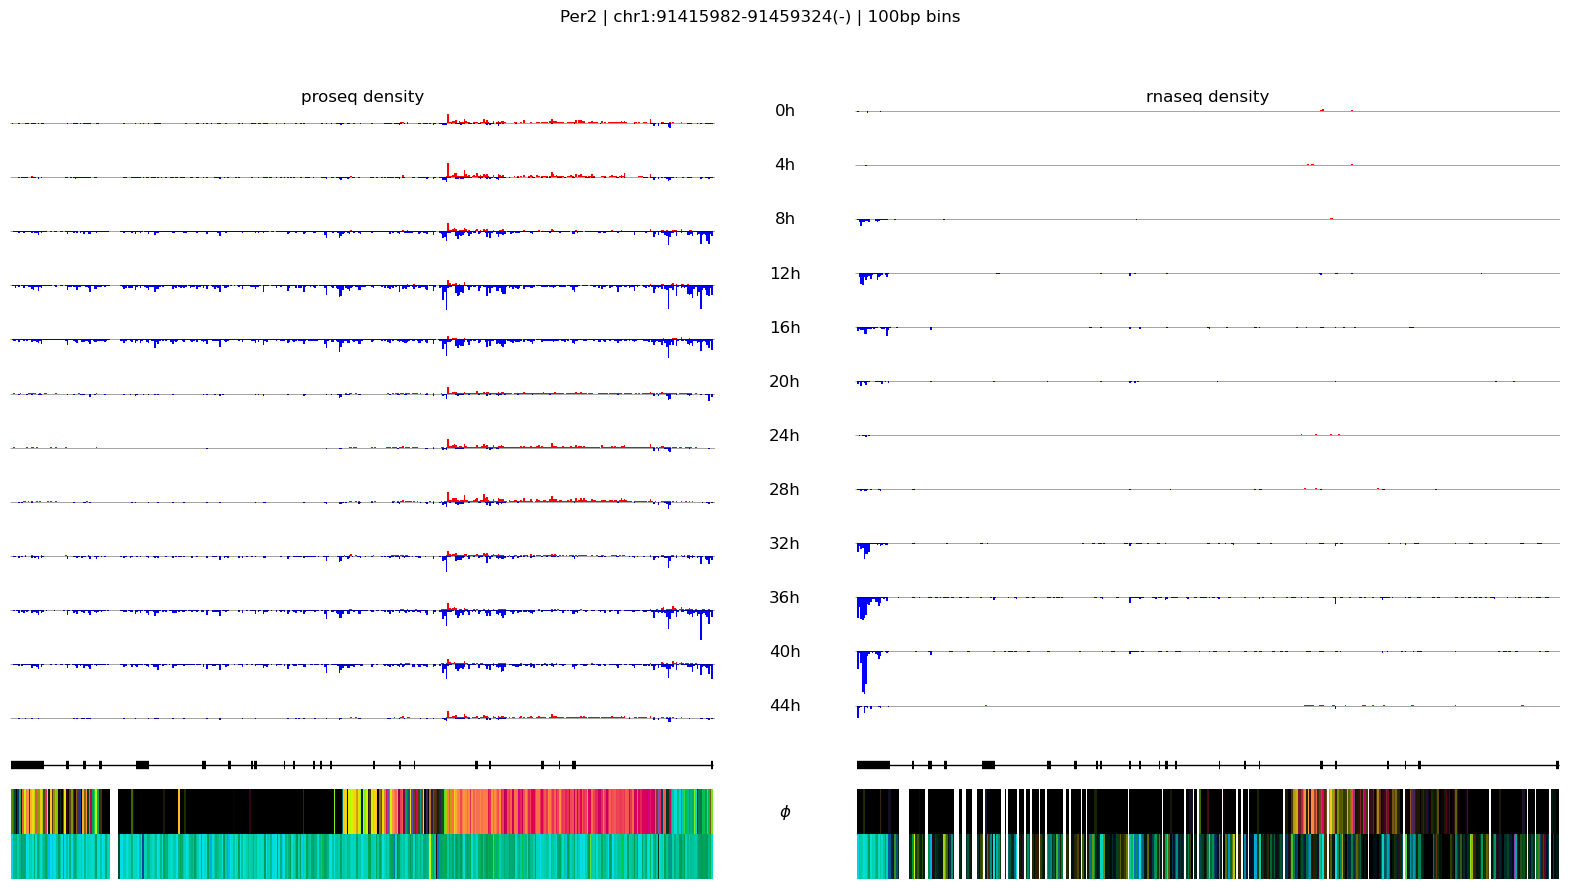

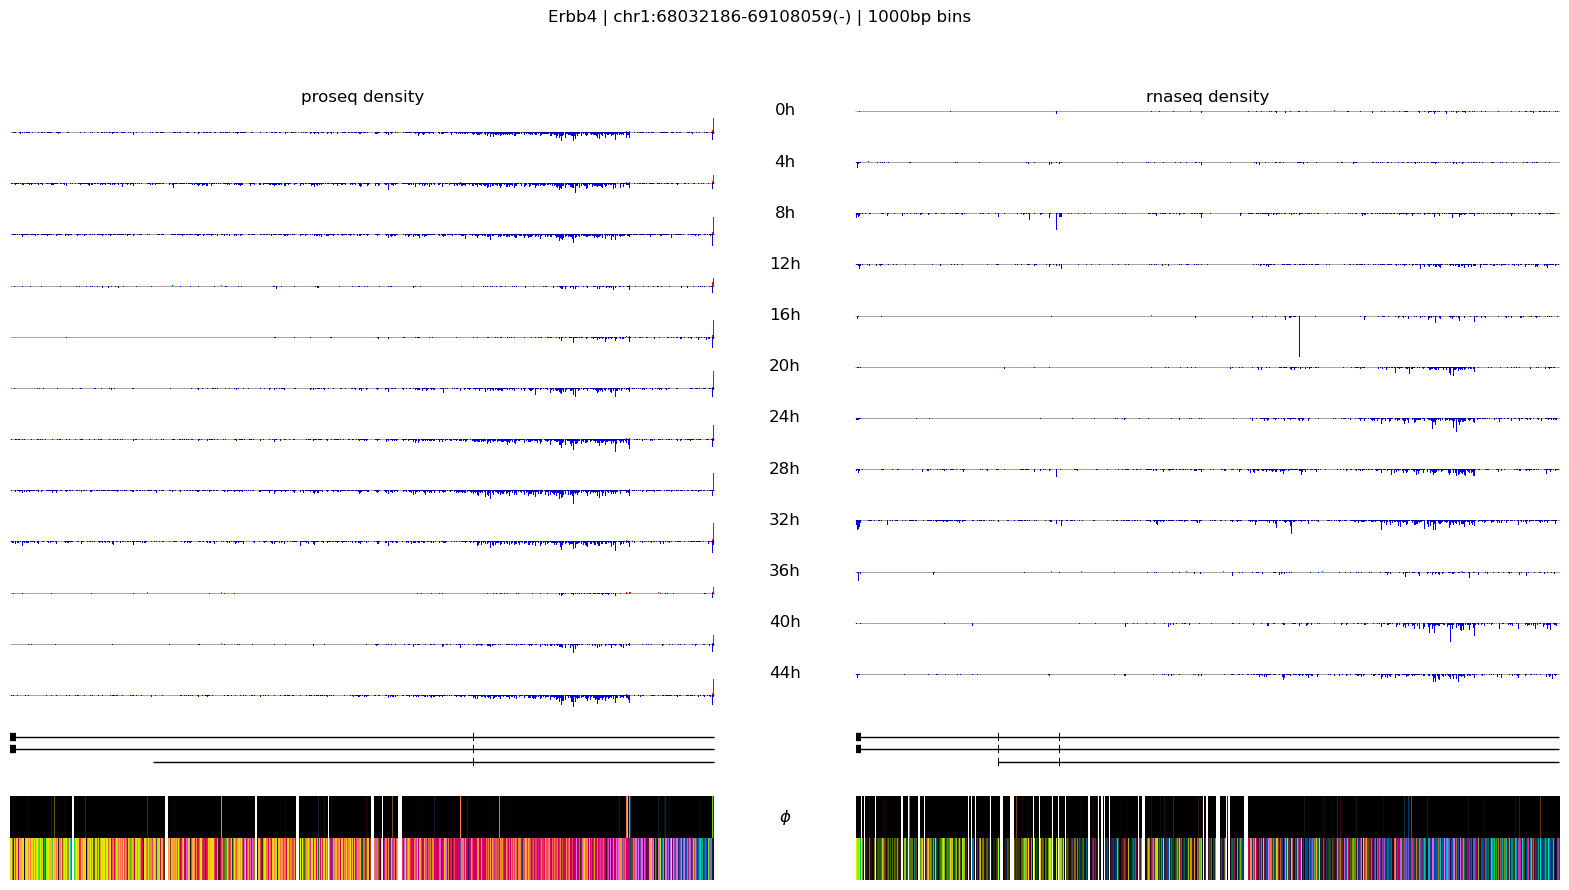

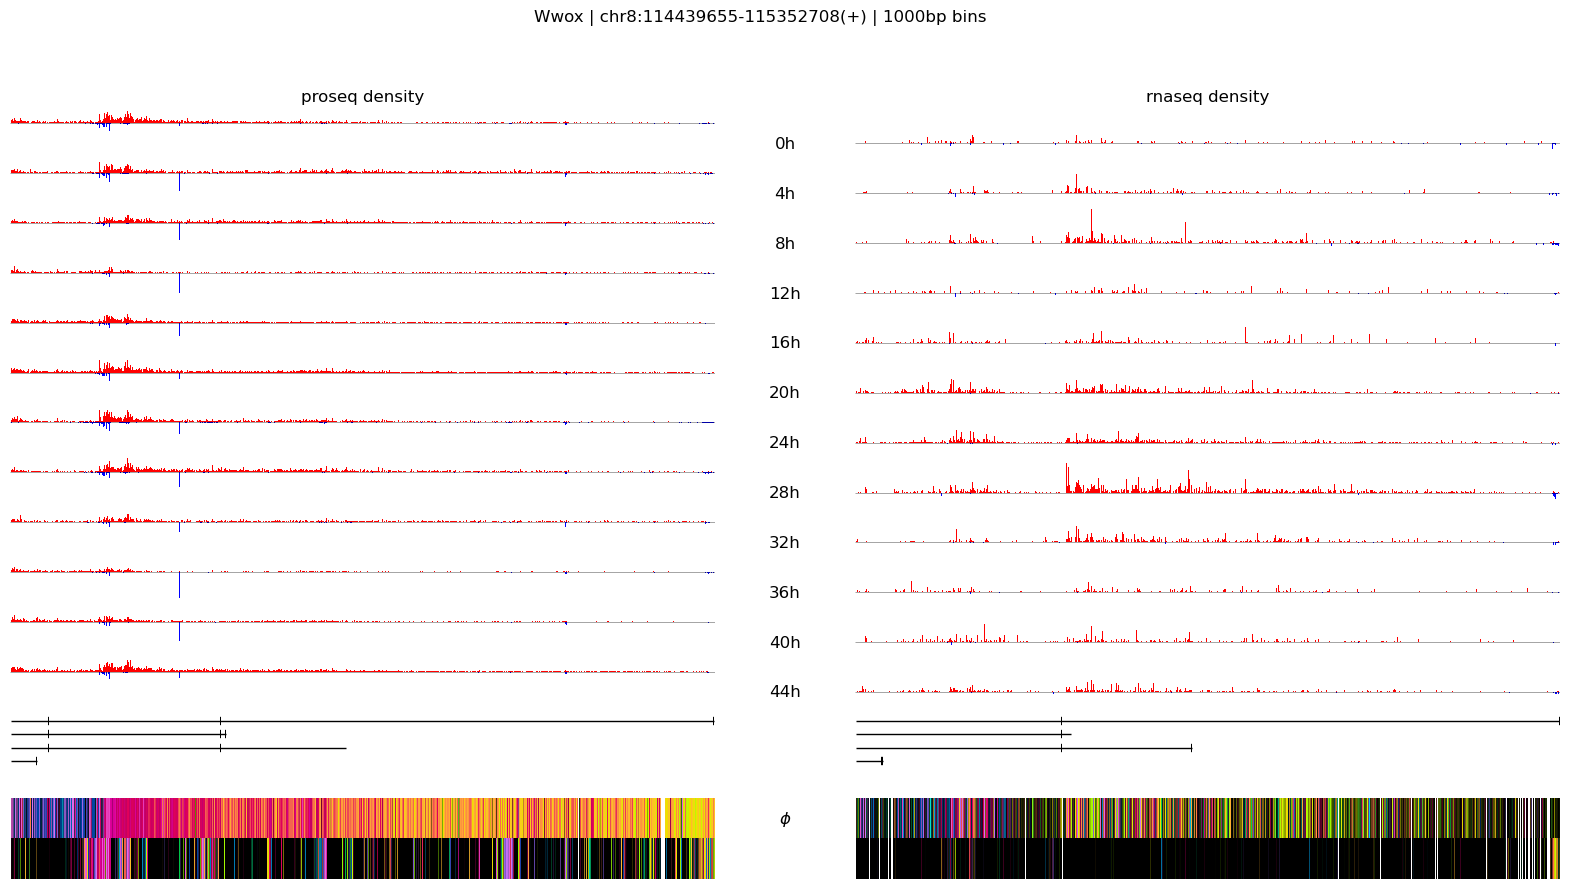

In [26]:
T = np.arange(0, 48, 4)
τ = 24
ω = 2*np.pi/τ
strand_idx = {'+': [col[-1]=='+' for col in PROSEQ[10000].columns], '-': [col[-1]=='-' for col in PROSEQ[10000].columns]}
strand_marker = {'+':'>', '-':'<'}

My_genes = ['Dbp','Nr1d1','Arntl','Npas2','Per2','Erbb4','Wwox']
#My_genes = core_circadian_genes

for my_gene in My_genes:
    print(my_gene)

    my_gtf = gene_gtf.loc[(gene_gtf.gene_name == my_gene),:]
    coord = my_gtf.loc[(my_gtf.feature == 'gene'),['chrom','start','end','strand']].iloc[0,:]

    my_transcripts = my_gtf.loc[(my_gtf.feature == 'transcript') & ((my_gtf.level == '1') | (my_gtf.level == '2')) & (my_gtf.transcript_type == 'protein_coding')]
    n_transcripts = my_transcripts.transcript_id.nunique()

    len = coord.end - coord.start
    if len < 2e5:
        bin_size = 100
    else:
        bin_size = 1000

    x_lims = [np.floor(coord.start/bin_size)*bin_size, np.ceil(coord.end/bin_size)*bin_size]
    proseq = PROSEQ[bin_size]
    rnaseq = RNASEQ[bin_size]

    # get data
    gene_exp = {}
    gene_exp['proseq'] = {}
    gene_exp['rnaseq'] = {}
    idx_p = (proseq.chr == coord.chrom) & (proseq.start >= coord.start) & (proseq.end <= coord.end)
    idx_r = (rnaseq.chr == coord.chrom) & (rnaseq.start >= coord.start) & (rnaseq.end <= coord.end)
    for strand in ['+','-']:

        gene_exp['proseq'][strand] = np.nan_to_num(proseq.loc[idx_p,strand_idx[strand]].values)
        gene_exp['proseq']['x'] = proseq.loc[idx_p,['start','end']].values.mean(1)

        gene_exp['rnaseq'][strand] = np.nan_to_num(rnaseq.loc[idx_r,strand_idx[strand]].values)
        gene_exp['rnaseq']['x'] = rnaseq.loc[idx_r,['start','end']].values.mean(1)
    
    # get y-axis limits
    ylim = {}
    for k in gene_exp.keys():
        ylim[k] = [-gene_exp[k]['-'].max(), gene_exp[k]['+'].max()]

    # plot binned coverage
    fig, axes = plt.subplots(ncols=2,nrows=T.shape[0]+2, figsize=(20,10), sharex=False, sharey=False, gridspec_kw={'height_ratios': [1]*T.shape[0]+[n_transcripts/2, 2]})
    for i,t in enumerate(T):
        for j,k in enumerate(['proseq','rnaseq']):
            ax = axes[i,j]
            ax.hlines(0, x_lims[0], x_lims[1], 'k', lw=.5, alpha=0.5)
            ax.bar(x=gene_exp[k]['x'], height=gene_exp[k]['+'][:,i], width=bin_size, color='r')
            ax.bar(x=gene_exp[k]['x'], height=-gene_exp[k]['-'][:,i], width=bin_size, color='b')
            ax.set_xlim(x_lims)
            ax.set_ylim(ylim[k])
            ax.set_xticks([])
            ax.set_yticks([])
            if t == T[0]:
                ax.set_title(f"{k} density")
            if t == T[-1]:
                ax.set_xlabel('Genomic position')
            if (k == 'rnaseq'):
                ax.text(x_lims[0]-0.1*(x_lims[-1] - x_lims[0]),0,f'{t}h', va='center', ha='center', fontsize=12, color='k')
            ax.set_xlim(x_lims)
            ax.axis('off')

    # plot gene isoforms and exons
    for j in range(2):
        ax = axes[-2,j]
        for t,transcript_id in enumerate(my_gtf.loc[(my_gtf.feature == 'transcript') & ((my_gtf.level == '1') | (my_gtf.level == '2')) & (my_gtf.transcript_type == 'protein_coding')].transcript_id.values):
            t_start,t_end = my_gtf.loc[(my_gtf.transcript_id == transcript_id) & (my_gtf.feature == 'transcript'),['start','end']].values[0]
            ax.hlines(-t, t_start, t_end, 'k', lw=1, alpha=1)
            # plot exons
            for exon in my_gtf.loc[(my_gtf.transcript_id == transcript_id) & (my_gtf.feature == 'exon'),['start','end']].itertuples(index=False):
                ax.hlines(-t,exon.start,exon.end, 'k', lw=6, alpha=1)

        ax.set_xlim(x_lims)
        ax.set_ylim(-n_transcripts-1, 1)
        ax.axis('off')

    # plot phase
    phi = {}
    phi['proseq'] = {}
    phi['rnaseq'] = {}
    for j,k in enumerate(['proseq','rnaseq']):

        N_pos = int( (gene_exp[k]['x'][-1] - gene_exp[k]['x'][0])//bin_size + 1 )
        Φ = np.ones((2,N_pos,3))
        for strand in ['+','-']:
            
            if k == 'proseq':
                y = np.log2(gene_exp[k][strand]+8)
            else:
                y = np.log2(gene_exp[k][strand]+8/rnaseq_read_len)

            N_bin, N_t = y.shape
            Λ = np.zeros([N_bin, N_t, N_t])

            σ2 = noise_params[k][bin_size]['a'] * np.exp(-noise_params[k][bin_size]['b'] * y ) + noise_params[k][bin_size]['c']
            σ2[y < noise_params[k][bin_size]['m_e_max']] = noise_params[k][bin_size]['e_max']
            for i in range(N_bin):
                Λ[i] = np.diag(1/σ2[i])

            mu, A, phi[k]['mean'], sig2_mu, sig2_A, phi[k]['var'] = FourierTransform_GLS(y,T,ω,Λ)
            idx_bin = np.where(gene_exp[k]['x'][:,None] == np.arange(gene_exp[k]['x'][0],gene_exp[k]['x'][-1]+1,bin_size)[None,:])[1]
            if strand == '+':
                Φ[0,idx_bin] = p2lc(phi[k]['mean'],amp=A,th_amp=0.5)
            else:
                Φ[1,idx_bin] = p2lc(phi[k]['mean'],amp=A,th_amp=0.5)

        ax = axes[-1,j]
        ax.imshow(Φ,aspect='auto',interpolation='none')
        my_xlim = [-.5-(coord.start-x_lims[0])/bin_size,N_pos-.5+(x_lims[1]-coord.end)/bin_size]
        ax.set_xlim(my_xlim)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        if k == 'rnaseq':
            ax.text(my_xlim[0]-0.1*(my_xlim[1]-my_xlim[0]), 0.5, r'$\phi$', va='center', ha='center', fontsize=12, color='k')

    fig.suptitle(f'{my_gene} | {coord.chrom}:{coord.start}-{coord.end}({coord.strand}) | {bin_size}bp bins')
    fig.savefig(f'fig/fig1/{my_gene}_{bin_size}bp.pdf')

    # phase inference in proseq
    if False:
        k = 'proseq'

        # center phi
        φ = phi[k]['mean']
        φ[φ - φ.mean() < -np.pi] += 2*np.pi
        φ[φ - φ.mean() > np.pi] -= 2*np.pi

        # keep phi in the neighborhood of its neighbors
        N_bin = φ.shape[0]
        for i in range(N_bin):
            idx = list(range(max(0,i-5),i)) + list(range(i+1,min(N_bin,i+6)))
            if φ[i] - φ[idx].mean() > np.pi:
                φ[i] -= 2*np.pi
            if φ[i] - φ[idx].mean() < -np.pi:
                φ[i] += 2*np.pi

        # get the phase slope and its error across space
        x = gene_exp[k]['x'] - gene_exp[k]['x'][0]
        β, σ2_β, R2 = linear_regression(x,φ)
        # translate beta (rad/bp) to velocity (bp/h)
        v_phi = 2*np.pi/(β[1]*τ*3600)

        # "Correct error" in the phase slope
        expected_shift = β[1]*x/(2*np.pi)*τ
        corrected_count = gene_exp[k]['count'] - expected_shift[:,None]
        data = corrected_count.mean(0)
        data /= data.sum()

        # objective function: sum of squared differences between data and model
        #fun = lambda x: np.sum((data - x[0]*periodic_gaussians(t, μ, x[1], τ))**2)
        μ = β[0]/(2*np.pi)*τ
        data = corrected_count.mean(0)
        dt = T[1]-T[0]
        # normalize data
        data /= (data.sum()*dt)
        
        # fit sigma minimizing the sum of squared differences between data and model (mixture of periodic gaussians and uniform)
        fun = lambda x: np.sum( (data - periodic_gaussians_unif(t=T, ρ=x[0], μ=x[1], σ2=x[2], τ=τ) )**2 )
        res = minimize(fun, x0=[0.5, μ, 2], bounds=[(0.01,.99),(-τ,τ), (0.01, None)])
        ρ_hat, μ_hat, σ2_hat = res.x

        #fun = lambda x: np.sum( (data - periodic_gaussians(t=T, μ=x[0], σ2=x[1], τ=τ) )**2 )
        #res = minimize(fun, [μ, 2], bounds=[(-τ,τ), (0.001, None)], method='L-BFGS-B')
        #μ_hat, σ2_hat = res.x

        # keep mu between 0 and τ
        if μ_hat < 0:
            μ_hat += τ
            
        # plot results
        fig, axes = plt.subplots(2,1,figsize=(10,5))

        ax = axes[0]
        ax.errorbar(x,y=φ,yerr=np.sqrt(phi[k]['var']),fmt='o')
        ax.plot(x,x*β[1]+β[0],'r-')
        #ax.plot(x,β[0]+x*(β[1]+2*np.sqrt(σ2_β[1,1])),'r:')
        #ax.plot(x,β[0]+x*(β[1]-2*np.sqrt(σ2_β[1,1])),'r:')

        ax.set_title(fr'{k} | $v_{{\phi}}$ = {v_phi:.2f} bp/s | $R^2$ = {R2:.2f}')
        ax.grid()

        ax = axes[1]

        ax.bar(T,data,width=4,alpha=.5,label='data')
        t_ = np.linspace(T[0],T[-1],1000)
        ax.plot(t_, periodic_gaussians_unif(t_,ρ_hat,μ_hat,σ2_hat,τ),'-',label='fit')
        ax.set_title(fr"$\mu = {μ_hat:.2f}, \rho = {ρ_hat:.2f}, \sigma={np.sqrt(σ2_hat):.2f}$")
        #ax.plot(t_, periodic_gaussians(t_,μ_hat,σ2_hat,τ),'-',label='fit')
        #ax.set_title(fr"$\mu = {μ_hat:.2f}, \sigma={np.sqrt(σ2_hat):.2f}$")
        ax.set_xlabel('time')
        ax.set_ylabel('expression')
        ax.legend()

        fig.suptitle(f'{my_gene}')
        fig.tight_layout()
        fig.savefig(f'fig/fig1/{my_gene}_{bin_size}bp_phase.pdf')

    

# Phase and amplitude of core circadian genes

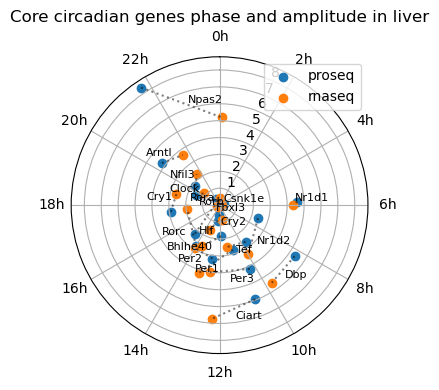

In [5]:
# get gene phase and amplitude
infile_proseq='../results/GRCm38/phase_amp/gene_phase_amp.csv'
infile_core_circadian_genes = '../resources/core_circadian_clock_genes.txt'
infile_rnaseq_transcript_table = f'~/RNAseq/results/Koike_Science_2012/kallisto/mrna_tpm_table.tab'

# read data
gene_phase_amp = {}
gene_phase_amp['proseq'] = pd.read_csv(infile_proseq, sep='\t')
gene_phase_amp['proseq']['gene_id'] = gene_phase_amp['proseq']['gene_id'].apply(remove_version_number)
core_circadian_genes = pd.read_csv(infile_core_circadian_genes, sep='\t')['mm10'].values
rnaseq_tpm_table = pd.read_csv(infile_rnaseq_transcript_table, sep='\t')

pseudo_count = .01

# parse gene name, id, type
# e.g. ENSMUST00000202651.3|ENSMUSG00000029238.11|OTTMUSG00000056120.1|OTTMUST00000138780.1|Clock-205|Clock|9744|protein_coding|
vals = ['transcript_id','gene_id','ignore','ignore','transcript_name','gene_name','ignore','gene_type']
for i,val in enumerate(vals):
    if val == 'ignore':
        continue
    rnaseq_tpm_table[val] = rnaseq_tpm_table['target_id'].str.split('|').str[i]
rnaseq_tpm_table.drop('target_id', axis=1, inplace=True)
# remove version
rnaseq_tpm_table['gene_id'] = rnaseq_tpm_table['gene_id'].apply(remove_version_number)

# sum by gene_id
rnaseq_tpm_table = rnaseq_tpm_table.groupby('gene_id').sum()

# get subset of core circadian genes 
idx = np.where( (gene_phase_amp['proseq'].gene_name.values[:,None] == core_circadian_genes).sum(1) )[0]
gene_phase_amp['proseq'] = gene_phase_amp['proseq'].loc[idx]
gene_phase_amp['proseq'].set_index('gene_id', inplace=True)

# get core circadian genes subset in rnaseq

rnaseq_tpm_table = rnaseq_tpm_table.loc[gene_phase_amp['proseq'].index]

# get phase and amplitude
T = np.arange(0, 48, 4)
ω = 2*np.pi/24
samples_id = [f'liver_CT{4*n}' for n in range(12)]
x = np.log2(rnaseq_tpm_table.loc[:,samples_id].values+pseudo_count)
φ, A, R2, pval, μ = FourierTransform(x,T,ω)

gene_phase_amp['rnaseq'] = pd.DataFrame({'gene_id':rnaseq_tpm_table.index, 'phase':φ, 'amplitude':A, 'R2':R2, 'pval':pval, 'mean':μ})


# Use unnormalized expression at each position for R
# exponential decay of R as a function of z :  R(x) = a * exp(-b * x) + c

#σ2_i = Noise_params['a'] * np.exp(-Noise_params['b'] * R2[i]*measurments[:,i] ) + Noise_params['c']
#r_i < Noise_params['m_err_max']] = Noise_params['err_max']
#Σ = np.diag(r_i)

# plot in polar coordinates
fig, ax = plt.subplots(figsize=(5,4), subplot_kw=dict(polar=True))

ax.scatter(gene_phase_amp['proseq']['phase'], gene_phase_amp['proseq']['amplitude'], label='proseq')
ax.scatter(gene_phase_amp['rnaseq']['phase'], gene_phase_amp['rnaseq']['amplitude'], label='rnaseq')
# connect same genes with lines and add gene names
for i in range(gene_phase_amp['proseq'].shape[0]):
    phase = np.array([gene_phase_amp['proseq']['phase'].iloc[i], gene_phase_amp['rnaseq']['phase'].iloc[i]])
    amp =   np.array([gene_phase_amp['proseq']['amplitude'].iloc[i], gene_phase_amp['rnaseq']['amplitude'].iloc[i]])
    ax.plot(phase,amp, 'k:', alpha=0.5)
    gene_name = gene_phase_amp['proseq']['gene_name'].iloc[i]

    # compute phase average keeping the difference between 0 and pi
    phase_mean = np.arctan2(np.mean(np.sin(phase)), np.mean(np.cos(phase)))
    amp_mean = np.mean(amp)

    ha = 'left' if phase.mean() < np.pi else 'right'
    va = 'bottom' if phase.mean() < np.pi/2 or phase.mean() > 3*np.pi/2 else 'top'
    ax.text(phase_mean, amp_mean, gene_name, fontsize=8, ha=ha, va=va)

ax.legend()
ax.set_xticks(np.linspace(0,2*np.pi,12,endpoint=False) )
ax.set_xticklabels([f'{t}h' for t in np.arange(0,24,2)])
#ax.set_yticks([])
ax.set_theta_zero_location("N")  # theta=0 at the top
ax.set_theta_direction(-1)  # theta increasing clockwise
ax.set_title('Core circadian genes phase and amplitude in liver')

fig.tight_layout()
fig.savefig('fig/fig1/core_circadian_genes_phase_amp.pdf')

## Accross all genes

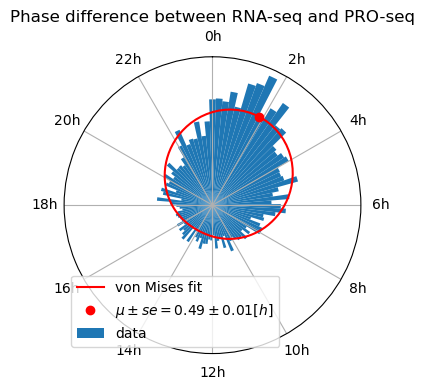

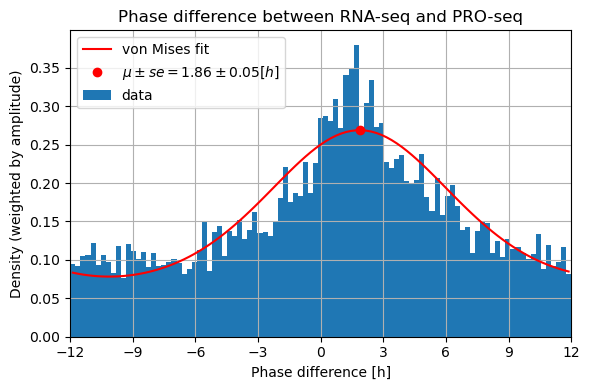

In [6]:
# input files
infile_proseq='../results/GRCm38/phase_amp/gene_phase_amp.csv'
infile_core_circadian_genes = '../resources/core_circadian_clock_genes.txt'
infile_rnaseq_transcript_table = f'~/RNAseq/results/Koike_Science_2012/kallisto/mrna_tpm_table.tab'

# read data
# proseq get phase amp table (already computed)
gene_phase_amp = {}
gene_phase_amp['proseq'] = pd.read_csv(infile_proseq, sep='\t')
gene_phase_amp['proseq']['gene_id'] = gene_phase_amp['proseq']['gene_id'].apply(remove_version_number)
# rnaseq: get tpm table
rnaseq_tpm_table = pd.read_csv(infile_rnaseq_transcript_table, sep='\t')

pseudo_count = .01

# parse gene name, id, type
# e.g. ENSMUST00000202651.3|ENSMUSG00000029238.11|OTTMUSG00000056120.1|OTTMUST00000138780.1|Clock-205|Clock|9744|protein_coding|
vals = ['transcript_id','gene_id','ignore','ignore','transcript_name','gene_name','ignore','gene_type']
for i,val in enumerate(vals):
    if val == 'ignore':
        continue
    rnaseq_tpm_table[val] = rnaseq_tpm_table['target_id'].str.split('|').str[i]
rnaseq_tpm_table.drop('target_id', axis=1, inplace=True)

# remove version
rnaseq_tpm_table['gene_id'] = rnaseq_tpm_table['gene_id'].apply(remove_version_number)

# sum by gene_id
rnaseq_tpm_table = rnaseq_tpm_table.groupby('gene_id').sum()

# get subset of core circadian genes
# rnaseq_tpm_table = rnaseq_tpm_table.loc[gene_phase_amp['proseq'].index]

# get phase and amplitude
T = np.arange(0, 48, 4)
ω = 2*np.pi/24
samples_id = [f'liver_CT{4*n}' for n in range(12)]
x = np.log2(rnaseq_tpm_table.loc[:,samples_id].values+pseudo_count)
φ, A, R2, pval, μ = FourierTransform(x,T,ω)

gene_phase_amp['rnaseq'] = pd.DataFrame({'gene_id':rnaseq_tpm_table.index, 'phase':φ, 'amplitude':A, 'R2':R2, 'pval':pval, 'mean':μ})

for k in gene_phase_amp.keys():
    gene_phase_amp[k].set_index('gene_id', inplace=True)

# get subset genes in both proseq and rnaseq
my_genes = list(set(gene_phase_amp['proseq'].index) & set(gene_phase_amp['rnaseq'].index))

for k in gene_phase_amp.keys():
    gene_phase_amp[k] = gene_phase_amp[k].loc[my_genes]

assert all(gene_phase_amp['proseq'].index == gene_phase_amp['rnaseq'].index)

# get phase difference 
dφ = (gene_phase_amp['rnaseq']['phase'] - gene_phase_amp['proseq']['phase']).values

# keep difference between -pi and pi
dφ[dφ < -np.pi] += 2*np.pi
dφ[dφ > np.pi] -= 2*np.pi

# plot phase difference distribution weighted by amplitude
n_bins = 100
bins = np.linspace(-np.pi, np.pi, n_bins)
w = .5*(gene_phase_amp['proseq']['amplitude'].values*gene_phase_amp['proseq']['R2'].values + gene_phase_amp['rnaseq']['amplitude'].values*gene_phase_amp['rnaseq']['R2'].values)
[h,x] = np.histogram(dφ, bins=bins, weights=w, density=True)
x = (x[1:] + x[:-1])/2

# fit a vonmises distribution
scale = 1
loc0 = 2/τ * 2*np.pi
κ0 = 10
# find the loc and κ that minimize mse between h and vm
fun = lambda θ: np.mean((vonmises.pdf(x, θ[0], loc=θ[1], scale=scale) - h)*(vonmises.pdf(x, θ[0], loc=θ[1], scale=scale) - h))
res = minimize(fun=fun, x0=[κ0, loc0], bounds=[(0, None), (-np.pi, np.pi)])
κ, loc = res.x
vm = vonmises.pdf(x, κ, loc, 1)

μ = loc
σ2 = (1 - jv(1,κ)/jv(0,κ))

# plot in polar coordinates
fig, ax = plt.subplots(figsize=(5,4), subplot_kw=dict(polar=True))

ax.bar(x, h, width=2*np.pi/(n_bins-1),label='data')
ax.plot(x, vm, 'r-', label='von Mises fit')
ax.plot(μ, vm.max(), 'ro', label=fr'$\mu\pm se = {round(μ,2)} \pm {round(np.sqrt(σ2/sum(w)),2)} [h]$')

ax.legend(loc='lower left')
ax.set_xticks(np.linspace(0,2*np.pi,12,endpoint=False) )
ax.set_xticklabels([f'{t}h' for t in np.arange(0,24,2)])
ax.set_yticks([])
ax.set_theta_zero_location("N")  # theta=0 at the top
ax.set_theta_direction(-1)  # theta increasing clockwise
ax.set_title('Phase difference between RNA-seq and PRO-seq')

fig.tight_layout()
fig.savefig('fig/fig1/phase_difference_polar.pdf')

# rescale x to hours
x = x/(2*np.pi) * τ
μ *= τ/(2*np.pi)
σ2 *= (τ/(2*np.pi))**2
# plot
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x, h, width=τ/(n_bins-1),label='data')
ax.plot(x, vm, 'r-', label='von Mises fit')
ax.plot(μ, vm.max(), 'ro', label=fr'$\mu\pm se = {round(μ,2)} \pm {round(np.sqrt(σ2/sum(w)),2)} [h]$')
#ax.axvline(μ+np.sqrt(σ2), color='r', linestyle=':')
#ax.axvline(μ-np.sqrt(σ2), color='r', linestyle=':')
ax.set_xticks(np.linspace(-τ/2,τ/2,9))

ax.set_xlim(-τ/2,τ/2)
ax.set_xlabel('Phase difference [h]')
ax.set_ylabel('Density (weighted by amplitude)')
ax.legend(loc='upper left')
ax.grid()
ax.set_title('Phase difference between RNA-seq and PRO-seq')

fig.tight_layout()
fig.savefig('fig/fig1/phase_difference.pdf')


# Use unnormalized expression at each position for R
# exponential decay of R as a function of z :  R(x) = a * exp(-b * x) + c

#σ2_i = Noise_params['a'] * np.exp(-Noise_params['b'] * R2[i]*measurments[:,i] ) + Noise_params['c']
#r_i < Noise_params['m_err_max']] = Noise_params['err_max']
#Σ = np.diag(r_i)


# Transport equation to simulate circadian transcription

# Analytical solution

Plotting


Text(0.5, 0, 'Genomic position')

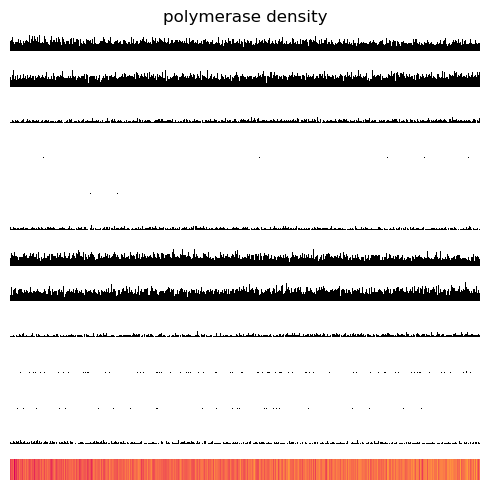

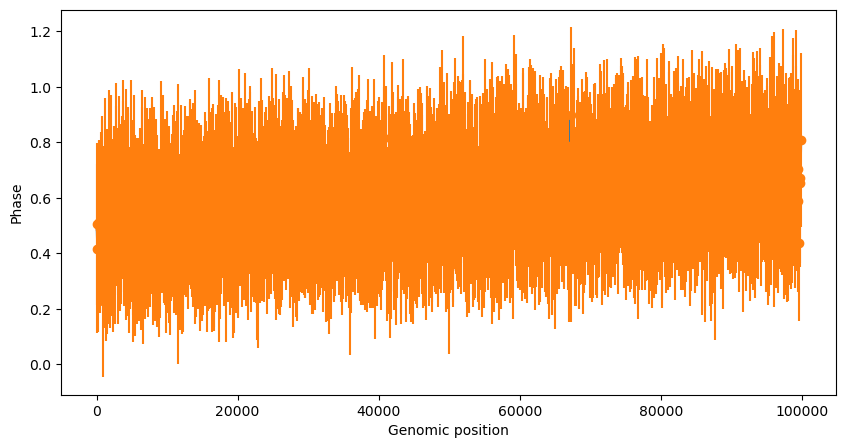

In [16]:

# Parameters
v = 42*3600                   # Constant velocity [bp/h]
x_max = 1e5                     # Maximum spatial domain [bp]
dx = 100                        # Spatial step size
t = np.arange(0,48,4)    # Time of the mesurements [h]
Nt = t.shape[0]                # Number of time points

# cyclic Gaussian source term
t0 = 2                          # Center time of the Gaussian source [h]
sigma = 3                       # Width of the Gaussian source [h]
τ = 24                          # Period of the oscillation [h]

# Spatial grid
x = np.arange(0, x_max, dx)
Nx = x.shape[0]                # Number of spatial points

# Analytical solution d rho / dt + v d rho / dx = S(x, t)
# S(x, t) = sum_n Gauss(x, t - t0 - nT, sigma)
def analytical_rho(x, t, n_terms):
    x = x[:, np.newaxis, np.newaxis]
    t = t[np.newaxis, :, np.newaxis]
    n_terms = n_terms[np.newaxis, np.newaxis, :]

    t_peak = t0 + n_terms * τ
    rho = np.exp(-(t - x/v - (t_peak))**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi * sigma**2))
    rho = rho.sum(axis=2)
    return rho

# compute n_terms: Truncate [t_0,t_end] ± 5 sigma
    
n_min = int(np.floor((t[0] - 5*sigma) / τ))
n_max = int(np.ceil((t[-1] + 5*sigma) / τ))
n_terms = np.arange(n_min, n_max + 1)
rho = analytical_rho(x, t, n_terms)

# Scale 
N = 200
rho = np.random.poisson(N*rho)

# Plotting
print("Plotting")
fig, axes = plt.subplots(Nt+1, 1, figsize=(5, 5))
f = 0
for i in range(Nt):
    ax = axes[f]
    ax.hlines(0, 0, x_max, 'k', lw=.5, alpha=0.5)
    ax.bar(x, height=rho[:,i],width=dx, color='k',label=f't = {t[i]:.1f}')
    ax.set_xticks([])
    ax.set_yticks([])
    if t[i] == t[0]:
        ax.set_title(f"polymerase density")
    if t[i] != t[0]:
        ax.set_yticklabels([])
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.1*rho.max())
    ax.set_ylabel(f'{t[i]}h')
    ax.axis('off')
    f += 1

# compute phase and amplitude
y = np.log2(rho+1)
Λ = np.zeros([Nx, Nt, Nt])
for i in range(Nx):
    # var(n) = 1/n
    Λ[i] = np.diag(rho[i]+.5)
#k = 'proseq'
#σ2 = noise_params[k]['a'] * np.exp(-noise_params[k]['b'] * y ) + noise_params[k]['c']
#σ2[y < noise_params[k]['m_e_max']] = noise_params[k]['e_max']
#for i in range(N_bin):
#    Λ[i] = np.diag(1/σ2[i])

ω = 2*np.pi/24
#σ2 = 10
#Λ = np.repeat( σ2*np.eye(Nt)[np.newaxis,:,:], Nx, axis=0)
# add some poisson noise

mu, A, phi, sig2_mu, sig2_A, sig2_phi = FourierTransform_GLS(y,t,ω,Λ)

Φ = np.ones((1,Nx,3))
Φ[0] = p2lc(phi)

ax = axes[-1]
ax.imshow(Φ,aspect='auto',interpolation='none')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
ax.set_ylabel(r'$\phi$')
ax.set_xlabel('Genomic position (1kb bins)')

fig.tight_layout()
fig.savefig('fig/fig1/transport_equation.pdf')


fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x,phi)
ax.errorbar(x,y=phi,yerr=2*np.sqrt(sig2_phi),fmt='o')
ax.set_ylabel('Phase')
ax.set_xlabel('Genomic position')
